 **Emotion Detection using NLP & Machine Learning**

 *Project Overview*

This project focuses on Emotion Detection from Text using Natural Language Processing (NLP) techniques and Machine Learning models.
We preprocess text data, convert it into numerical form, and train multiple models to classify emotions.

Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset



In [6]:
df = pd.read_csv('train.txt',sep = ';',header = None,names = ['text','emotion'])

In [7]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
df.isnull().sum()

,0
text,0
emotion,0


Encode Emotions (Label Encoding)

In [9]:
unique_emotions = df['emotion'].unique()
emotion_numbers = {}
i = 0
for emo in unique_emotions:
  emotion_numbers[emo] = i
  i +=1

df['emotion'] = df['emotion'].map(emotion_numbers)

In [10]:
df

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,5
15998,i feel like this was such a rude comment and i...,1


Text **Preprocessing**

Lowercase

In [11]:
df['text'] = df['text'].apply(lambda x : x.lower())

Remove Punctuation

In [12]:
import string

def remove_punc(txt):
  return txt.translate(str.maketrans('','',string.punctuation))


In [13]:
df['text'] = df['text'].apply(remove_punc)

Remove Numbers

In [14]:
def remove_numbers(txt):
    new = ""
    for i in txt:
        if not i.isdigit():
            new = new + i
    return new

df['text'] = df['text'].apply(remove_numbers)

remove_emojis

In [15]:
def remove_emojis(txt):
    new = ""
    for i in txt:
        if i.isascii():
            new += i
    return new

df['text'] = df['text'].apply(remove_emojis)

Remove Stopwords

In [16]:
import nltk

In [17]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [18]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [19]:
stop_words = set(stopwords.words('english'))


In [20]:
df.loc[1]['text']

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [21]:
def remove(txt):
  words = txt.split()
  cleaned = []
  for i in words:
    if not i in stop_words:
      cleaned.append(i)

  return ' '.join(cleaned)

In [22]:
df['text'] = df['text'].apply(remove)

In [23]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [24]:
df.head()

,text,emotion
0,didnt feel humiliated,0
1,go feeling hopeless damned hopeful around some...,0
2,im grabbing minute post feel greedy wrong,1
3,ever feeling nostalgic fireplace know still pr...,2
4,feeling grouchy,1


Train Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.20, random_state=42)

Bag of Words + Naive Bayes

In [26]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)


nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)


pred_bow = nb_model.predict(X_test_bow)
print(accuracy_score(y_test, pred_bow))

0.768125


In [27]:
pred_bow

array([0, 5, 0, ..., 5, 5, 0])

TF-IDF + Naive Bayes

In [28]:

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


nb2_model = MultinomialNB()
nb2_model.fit(X_train_tfidf,y_train)

MultinomialNB()

In [29]:
y_pred = nb2_model.predict(X_test_tfidf)

In [30]:
print(accuracy_score(y_test, y_pred))

0.6609375


Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
logistic_model = LogisticRegression(max_iter=1000)

In [33]:
logistic_model.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [34]:
log_pred = logistic_model.predict(X_test_tfidf)

In [35]:
print(accuracy_score(y_test,log_pred ))

0.8628125


Confusion Matrix Add Karo

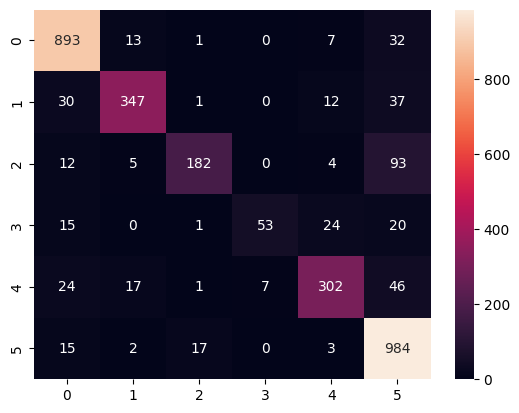

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

Model Save Karo

In [37]:
import joblib

joblib.dump(logistic_model, "emotion_model.pkl")
joblib.dump(tfidf_vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

Prediction Function

In [42]:
def predict_emotion(text):
    text = text.lower()
    text = remove_punc(text)
    text = remove_numbers(text)
    text = remove(text)

    vector = tfidf_vectorizer.transform([text])
    prediction = logistic_model.predict(vector)

    return prediction

print(predict_emotion("I am very happy today"))

[5]
